# Задача 1. Описова статистика: реальні дані (ceosal1)

**Датасет:** `ceosal1` (Wooldridge) — дані про компенсацію CEO великих корпорацій США, 209 спостережень.

| Змінна | Опис |
|---|---|
| `salary` | річна зарплата + бонуси CEO, тис. $ |
| `pcsalary` | % зміни зарплати відносно минулого року |
| `sales` | дохід фірми від продажів за рік, млн $ |
| `roe` | рентабельність власного капіталу, % |
| `age` | вік CEO, роки — **змодельовано**: `N(53, 6.5²)` (в оригінальному наборі відсутній) |

Оригінальний набір містить й інші колонки (`ros`, `indus`, `finance`, `lsalary`, ...) — вони нам не потрібні.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.datasets import get_rdataset

sns.set_theme(style="whitegrid")
SEED = 42

In [2]:
raw = get_rdataset("ceosal1", "wooldridge").data

df = raw[["salary", "pcsalary", "sales", "roe"]].copy()

# age відсутній в оригінальних даних -> симулюємо N(53, 6.5^2)
rng = np.random.default_rng(SEED)
df["age"] = rng.normal(loc=53, scale=6.5, size=len(df))

df = df[["salary", "pcsalary", "age", "sales", "roe"]]
df.head()

,salary,pcsalary,age,sales,roe
0,1095,20,54.980661,27595.000000,14.1
1,1001,32,46.240103,9958.000000,10.9
2,1122,9,57.877933,6125.899902,23.5
3,578,-9,59.113671,16246.000000,5.9
4,1368,7,40.318271,21783.199219,13.8


In [3]:
print(df.shape)
df.describe().round(2)

(209, 5)


,salary,pcsalary,age,sales,roe
count,209.00,209.00,209.00,209.00,209.00
mean,1281.12,13.28,52.73,6923.79,17.18
std,1372.35,32.63,5.78,10633.27,8.52
min,223.00,-61.00,39.14,175.20,0.50
25%,736.00,-1.00,48.67,2210.30,12.40
50%,1039.00,9.00,52.68,3705.20,15.50
75%,1407.00,20.00,56.46,7177.00,20.00
max,14822.00,212.00,71.94,97649.90,56.30


## Частина 1

### (а) Міри положення для `salary`

In [4]:
x = df["salary"]

measures = pd.Series({
    "Середнє": x.mean(),
    "5%-усічене середнє": stats.trim_mean(x, 0.05),
    "Медіана": x.median(),
    "Нижній квартиль (Q1)": x.quantile(0.25),
    "Верхній квартиль (Q3)": x.quantile(0.75),
    "Нижній 5%-квантиль": x.quantile(0.05),
    "Верхній 5%-квантиль (95%)": x.quantile(0.95),
}, name="salary, тис. $")
measures.round(2).to_frame()

,"salary, тис. $"
Середнє,1281.12
5%-усічене середнє,1100.88
Медіана,1039.00
Нижній квартиль (Q1),736.00
Верхній квартиль (Q3),1407.00
Нижній 5%-квантиль,450.00
Верхній 5%-квантиль (95%),2295.40


**Економічна інтерпретація (salary, тис. $):**

- **Середнє** — арифметична річна компенсація CEO, якби її поділили порівну між усіма; чутливе до відхилень.
- **5%-усічене середнє** — середня компенсація CEO після відкидання по 5% найменших і найбільших виплат; відкидає відхилення.
- **Медіана** — обирає знчення, яке знаходиться по середині вибірки; найкраща оцінка компенсації.
- **Нижній квартиль Q1** — 25% CEO отримують не більше за це значення; межа найменш оплачуваної чверті.
- **Верхній квартиль Q3** — 25% CEO отримують більше за це значення; поріг найбільш оплачуваної чверті.
- **Нижній 5%-квантиль** — лише 5% CEO заробляють менше.
- **Верхній 5%-квантиль** — лише 5% CEO заробляють більше.

### (б) ECDF

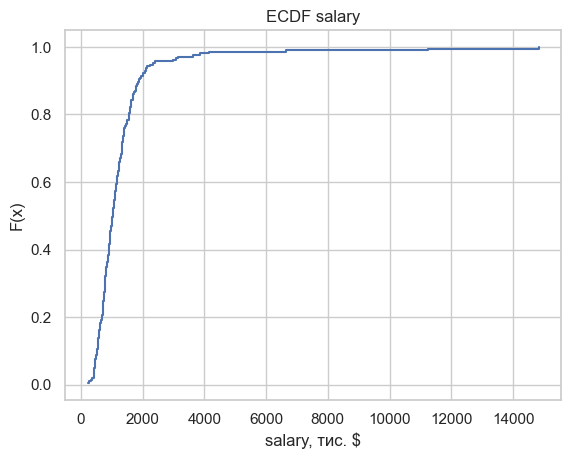

F^-1(0.1) = 525  F^-1(0.9) = 1900
F(1000) = 0.4785  1-F(2500) = 0.0431


In [5]:
xs = np.sort(x)
n = len(xs)
F = lambda t: (xs <= t).mean()          # ECDF
Finv = lambda p: np.quantile(xs, p, method="inverted_cdf")  # F^-1(p)

plt.step(xs, np.arange(1, n+1)/n, where="post")
plt.xlabel("salary, тис. $"); plt.ylabel("F(x)"); plt.title("ECDF salary"); plt.show()

print("F^-1(0.1) =", Finv(0.1), " F^-1(0.9) =", Finv(0.9))
print("F(1000) =", round(F(1000),4), " 1-F(2500) =", round(1-F(2500),4))

- F⁻¹(0.1) = 525: 10% CEO отримують не більше 525 тис. $ (нижній дециль).
- F⁻¹(0.9) = 1900: 90% CEO отримують не більше 1900 тис. $, лише 10% заробляють більше.
- F(1000) = 0.479: близько 48% CEO отримують до 1 млн $ включно.
- 1 − F(2500) = 0.043: лише ≈4.3% CEO отримують більше 2.5 млн $.

### (в) Гістограма та box-plot

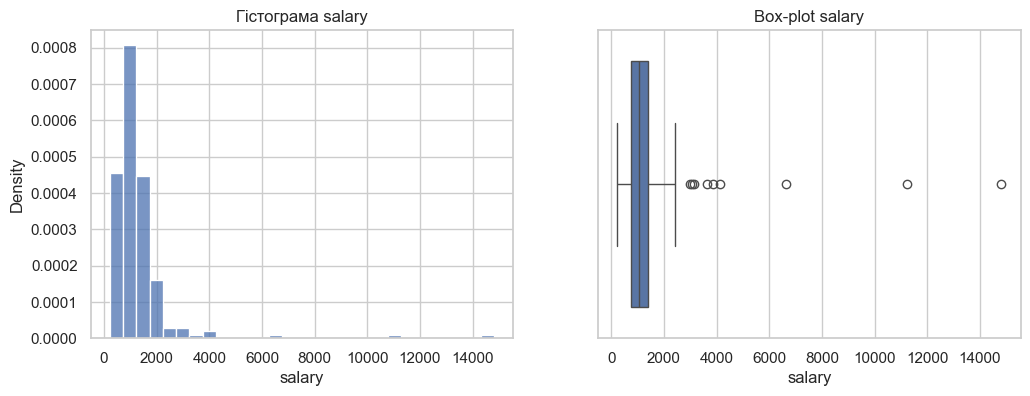

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(x, stat="density", ax=ax[0]); ax[0].set_title("Гістограма salary")
sns.boxplot(x=x, ax=ax[1]); ax[1].set_title("Box-plot salary")
plt.show()

Площа прямокутника гістограми (при density) = частка спостережень у цьому інтервалі (≈ ймовірність потрапити в нього). Загальна площа = 1.

Box-plot: лінія в «ящику» — медіана (1039), краї ящика — Q1 (736) і Q3 (1407), «вуса» йдуть до найменшого/найбільшого значення в межах 1.5·IQR, точки за вусами — викиди (дуже високі зарплати, до 14 822).

### (г) Висновок про розподіл, коефіцієнт асиметрії

In [7]:
g1 = stats.skew(x)   # коефіцієнт Фішера-Пірсона
print("skew =", round(g1, 3))
print("mean =", round(x.mean(),1), " median =", x.median())
print("викидів за правилом 1.5*IQR:", (x > x.quantile(.75) + 1.5*(x.quantile(.75)-x.quantile(.25))).sum())

skew = 6.855
mean = 1281.1  median = 1039.0
викидів за правилом 1.5*IQR: 9


Розподіл **сильно правосторонньо асиметричний**: основна маса CEO отримує 500–1500 тис. $, але є довгий правий хвіст і 9 викидів. Коефіцієнт асиметрії Фішера-Пірсона ≈ 6.86 ≫ 0 — підтверджує це. Середнє (1281) помітно більше за медіану (1039) і усічене середнє (1101), тож середнє через викиди не є хорошою мірою «типової» зарплати; краще дивитись на медіану й усічене середнє.

### (ґ) Метод вибору bins (seaborn), bins=150 та bins=3

Кількість бінів за правилом Фрідмана-Діаконіса: 65


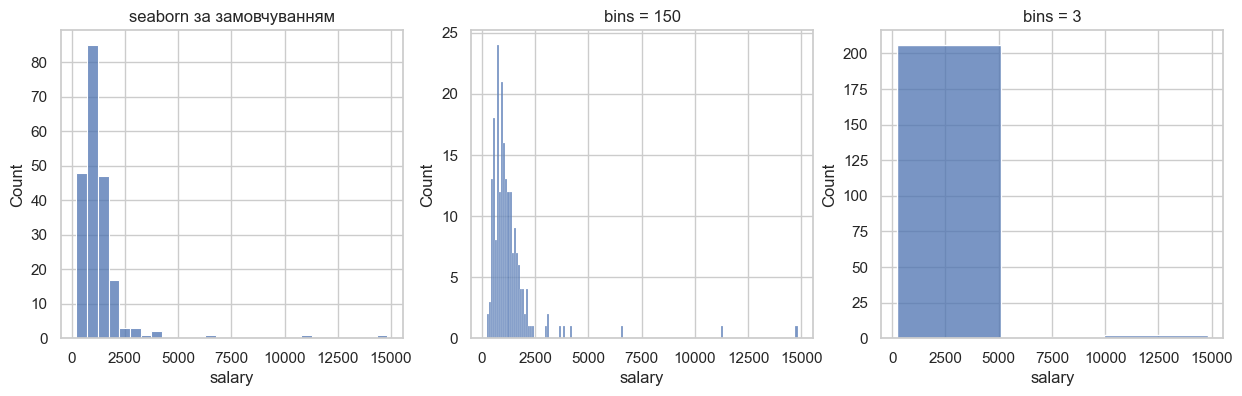

In [8]:
print("Кількість бінів за правилом Фрідмана-Діаконіса:",
      len(np.histogram_bin_edges(x, bins="fd")) - 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(x, ax=ax[0]).set_title("seaborn за замовчуванням")
sns.histplot(x, bins=150, ax=ax[1]).set_title("bins = 150")
sns.histplot(x, bins=3, ax=ax[2]).set_title("bins = 3")
plt.show()

Seaborn за замовчуванням для одновимірної гістограми обирає кількість бінів за правилом **Фрідмана-Діаконіса**: ширина біна h = 2·IQR·n^(−1/3) (стійке до викидів). Для наших даних це ≈ 65 бінів (у нових версіях seaborn при `bins="auto"` обирається максимум із правил Стерджеса і FD).

- **bins=150**: занадто детально — стовпчики шумні, багато порожніх, видно випадковість вибірки, а не форму розподілу.
- **bins=3**: занадто узагальнено — майже все в одному стовпчику, форма розподілу (хвіст, мода) втрачена.

Висновок: ширина біна — компроміс між шумом і втратою інформації.

### (д) ln(salary)

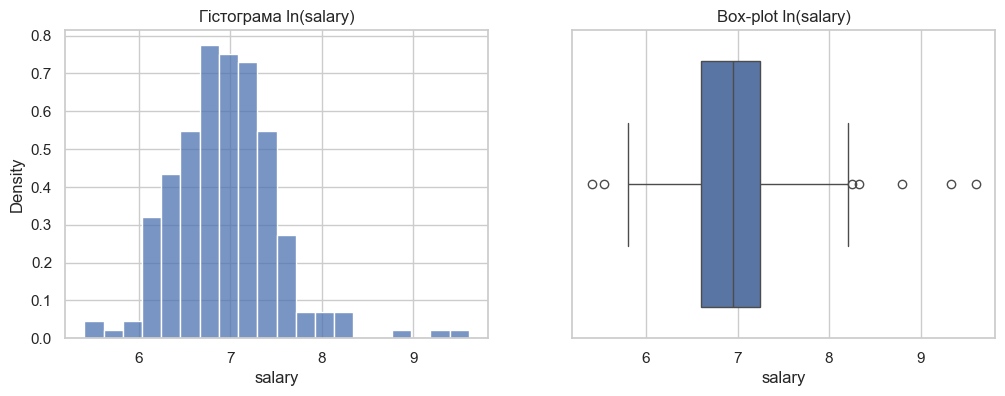

mean = 6.95  median = 6.946  skew = 0.88
exp(mean) = 1043.6  exp(median) = 1039.0


In [9]:
lx = np.log(x)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(lx, stat="density", ax=ax[0]); ax[0].set_title("Гістограма ln(salary)")
sns.boxplot(x=lx, ax=ax[1]); ax[1].set_title("Box-plot ln(salary)")
plt.show()
print("mean =", round(lx.mean(),3), " median =", round(lx.median(),3), " skew =", round(stats.skew(lx),3))
print("exp(mean) =", round(np.exp(lx.mean()),1), " exp(median) =", round(np.exp(lx.median()),1))

Логарифм робить розподіл значно симетричнішим: skew впав з 6.86 до ≈0.88, викиди майже зникли, гістограма схожа на дзвін. Середнє (6.95) і медіана (6.946) майже співпали, тобто розподіл ln(salary) близький до симетричного (приблизно нормального). Економічно: зарплати розподілені приблизно **лог-нормально** — різницю між CEO краще описувати в відсотках (у разів), а не в абсолютних доларах. exp(середнє ln) ≈ 1044 тис. $ — геометричне середнє, близьке до медіани.

## Частина 2

### (а) Кореляція Пірсона, heatmap

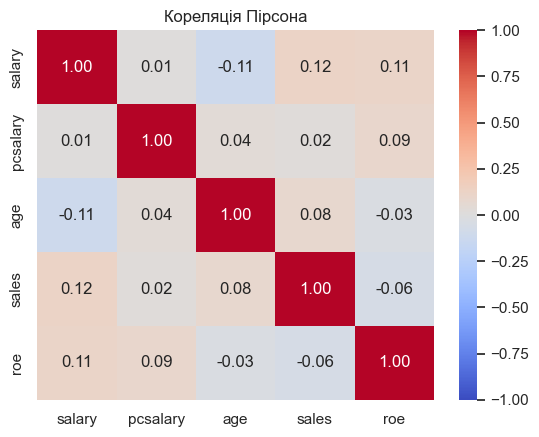

In [10]:
pear = df.corr(method="pearson")
sns.heatmap(pear, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Кореляція Пірсона"); plt.show()

Найсильніша кореляція — salary–sales ≈ 0.12 (слабка додатна, відповідно більші фірми трохи більше платять), salary–roe ≈ 0.11 (слабка додатна). Решта близькі до 0. Вік (змодельований незалежно) з усім некорельований (|r|<0.1) — як і очікувалось. Загалом лінійні зв'язки слабкі.

### (б) Pairplot, кореляція Спірмена

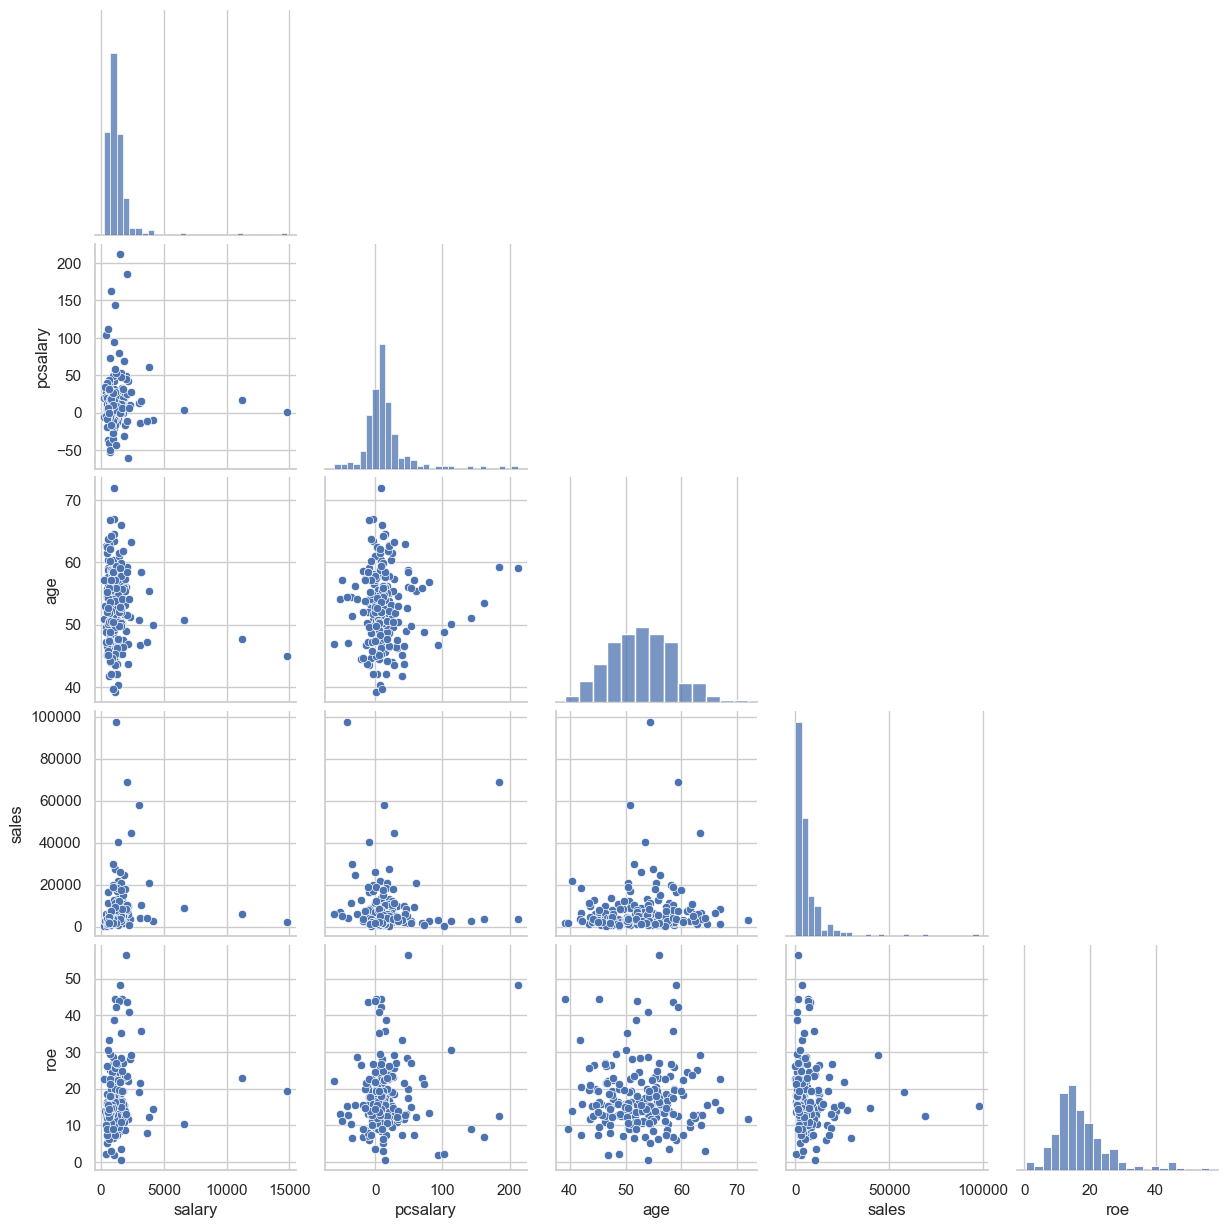

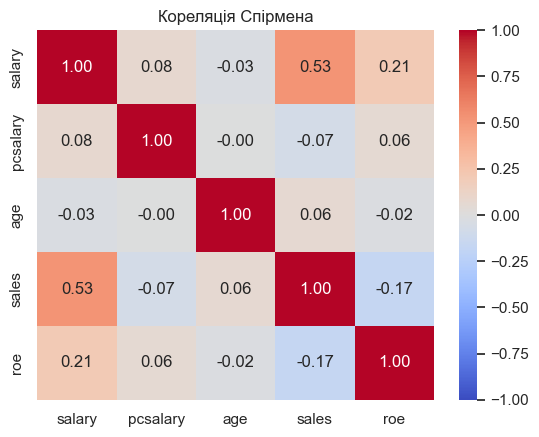

          salary  pcsalary   age  sales   roe
salary      0.00      0.07  0.08   0.41  0.09
pcsalary    0.07      0.00 -0.04  -0.09 -0.03
age         0.08     -0.04  0.00  -0.02  0.01
sales       0.41     -0.09 -0.02   0.00 -0.12
roe         0.09     -0.03  0.01  -0.12  0.00


In [11]:
sns.pairplot(df, corner=True)
plt.show()
spear = df.corr(method="spearman")
sns.heatmap(spear, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Кореляція Спірмена"); plt.show()
print((spear - pear).round(2))

На pairplot видно, що salary і sales сильно скошені, більшість точок збита біля нуля, а кілька викидів «тягнуть» лінійну кореляцію — тому Пірсон тут не дуже доречний (він чутливий до викидів і вимагає лінійності). Спірмен для salary–sales ≈ **0.53** (проти 0.12 у Пірсона): зв'язок є й монотонний (більші фірми платять більше), але його маскують викиди. Також salary–roe: 0.21 проти 0.11. Для age Спірмен, як і Пірсон, ≈ 0.

### (в) Різниця між Пірсоном і Спірменом

**Пірсон** міряє, наскільки точки лежать на *прямій* лінії (лінійний зв'язок). **Спірмен** — це Пірсон, порахований за рангами, тому він міряє, наскільки зв'язок *монотонний* (чим більше X, тим більше Y — необов'язково по прямій). Якщо залежність лінійна, обидва коефіцієнти близькі; якщо залежність монотонна, але вигнута (наприклад, експонента), то Спірмен буде майже 1, а Пірсон — менший. Також Пірсон чутливий до викидів, а Спірмен — ні.

### (г) Підвибірки: age < 50 та age > 50

66 143
         young     old
count     66.0   143.0
mean    1488.1  1185.6
std     2192.4   727.6
min      360.0   223.0
25%      723.0   775.0
50%     1013.5  1045.0
75%     1332.5  1450.0
max    14822.0  6640.0
skew: 4.87 3.56


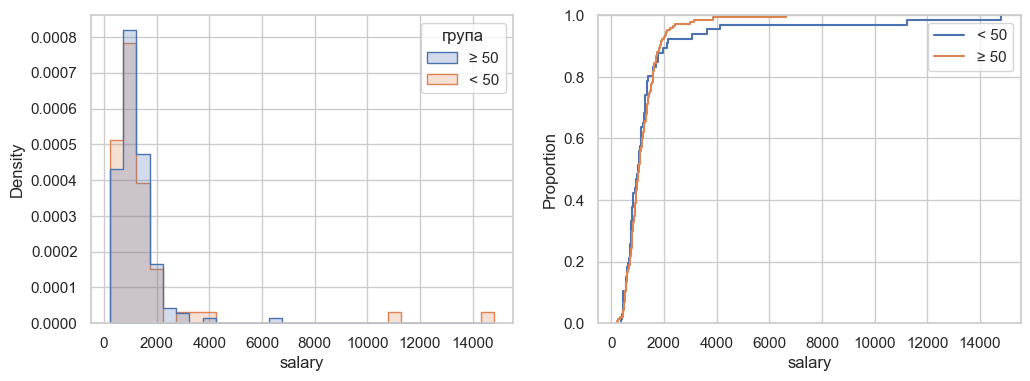

In [12]:
young, old = df[df.age < 50], df[df.age >= 50]
print(len(young), len(old))
print(pd.DataFrame({"young": young.salary.describe(), "old": old.salary.describe()}).round(1))
print("skew:", round(stats.skew(young.salary),2), round(stats.skew(old.salary),2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df.assign(група=np.where(df.age < 50, "< 50", "≥ 50")), x="salary",
             hue="група", stat="density", common_norm=False, element="step", ax=ax[0])
sns.ecdfplot(young.salary, label="< 50", ax=ax[1]); sns.ecdfplot(old.salary, label="≥ 50", ax=ax[1])
ax[1].legend(); plt.show()

Молодші (<50): середнє 1488 > медіани 1013, великий розкид (std 2192) через кілька дуже високих зарплат. Старші (≥50): середнє 1186, std 728. Медіани майже однакові (≈1010 і ≈1045), тобто «типова» зарплата від віку не залежить; різниця середніх повністю пояснюється викидами в малій групі (66 осіб). ECDF майже збігаються, що узгоджується з тим, що age згенерований незалежно від salary. Висновок: міри положення (медіана) стійкі, а середнє і розсіювання (std) сильно залежать від викидів.

## Частина 3

### (а) Таблиця спряженості 2×3 (S × A)

In [13]:
S = pd.cut(df.salary, [-np.inf, 700, 1300, np.inf], right=False, labels=["S1", "S2", "S3"])
A = pd.cut(df.age, [-np.inf, 55, np.inf], right=False, labels=["A1", "A2"])
abs_t = pd.crosstab(A, S, margins=True)
rel_t = pd.crosstab(A, S, margins=True, normalize="all")
rel_row = pd.crosstab(A, S, normalize="index")
print(abs_t); print(rel_t.round(3)); print(rel_row.round(3))

salary  S1   S2  S3  All
age                     
A1      27   66  44  137
A2      15   35  22   72
All     42  101  66  209
salary     S1     S2     S3    All
age                               
A1      0.129  0.316  0.211  0.656
A2      0.072  0.167  0.105  0.344
All     0.201  0.483  0.316  1.000
salary     S1     S2     S3
age                        
A1      0.197  0.482  0.321
A2      0.208  0.486  0.306


### (б) Інтерпретація n12, h12, n1·, h1·

- **n₁₂ = 66**: у вибірці 66 CEO молодших за 55 років із зарплатою 700–1300 тис. $.
- **h₁₂ = 66/209 ≈ 0.316**: це 31.6% усіх CEO належать одночасно до A1 і S2.
- **n₁· = 137**: усього 137 CEO молодші за 55 років (сума по рядку).
- **h₁· = 137/209 ≈ 0.656**: 65.6% усіх CEO молодші за 55.

### (в) Крамер V / χ²

In [14]:
chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(A, S))
V = np.sqrt(chi2 / (len(df) * (min(2, 3) - 1)))
print(f"chi2 = {chi2:.3f}, dof = {dof}, p = {p:.3f}, Cramer V = {V:.3f}")

chi2 = 0.068, dof = 2, p = 0.967, Cramer V = 0.018


χ² ≈ 0.07 (2 ступені свободи), p ≈ 0.97, V Крамера ≈ 0.02. Гіпотезу про незалежність не відхиляємо: залежність між віком і рівнем зарплати практично відсутня (розподіл зарплатних груп майже однаковий у A1 і A2: ≈20/48/31% проти ≈21/49/31%). Це очікувано, бо age змодельований незалежно від salary; на реальних даних такого висновку про зв'язок віку та зарплати робити не можна.